## 1. Import các thư viện cần thiết

**Mục tiêu:**  
Import các thư viện Pandas, NumPy và Matplotlib để xử lý dữ liệu, tính toán và trực quan hóa sau này.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Xây dựng mô hình Decision Tree Regressor từ đầu

Các thành phần chính:

- **Node**: lưu thông tin của từng nút trong cây.
- **DecisionTreeRegressor**: quản lý toàn bộ quá trình xây dựng và dự đoán bằng cây quyết định.
- Sử dụng phương pháp đệ quy để chia dữ liệu thành các nút con.
- Điều kiện dừng gồm:
  - Đạt độ sâu tối đa (`max_depth`).
  - Số lượng mẫu nhỏ hơn `min_samples_split`.
  - Phương sai của biến mục tiêu bằng 0.
- Giá trị dự đoán tại nút lá được tính bằng trung bình của các mẫu trong nút đó.

In [2]:
# CÀI ĐẶT CÂY QUYẾT ĐỊNH 

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature       
        self.threshold = threshold   
        self.left = left             
        self.right = right           
        self.value = value           

    def is_leaf_node(self): # Kiểm tra xem nút có phải là nút lá không
        return self.value is not None # Nếu giá trị không phải None thì đây là nút lá

class DecisionTreeRegressor:
    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        max_features=None,
        random_state=None
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.root = None

        if random_state is not None:
            np.random.seed(random_state)

    def fit(self, X, y): 
        # 1. HÀM FIT: Nhận dữ liệu và bắt đầu mọc cây
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        y_array = y.values if isinstance(y, pd.Series) else y
        self.root = self._grow_tree(X_array, y_array)

    def _grow_tree(self, X, y, depth=0):
            n_samples, n_feats = X.shape

            # Điều kiện biên để dừng phân tách cây
            if (
                (self.max_depth is not None and depth >= self.max_depth) # Dừng nếu đạt độ sâu tối đa
                or n_samples < self.min_samples_split # Dừng nếu số mẫu nhỏ hơn ngưỡng
                or np.var(y) == 0.0 # Dừng nếu phương sai bằng 0
            ):

               leaf_value = np.mean(y) # Giá trị lá là trung bình của y
               return Node(value=leaf_value)
            
            feat_idxs = np.arange(n_feats)
            if self.max_features is not None:
                feat_idxs = np.random.choice(
                    feat_idxs,
                    min(self.max_features, n_feats),
                    replace=False
                )

            # Tìm kiếm điểm chia tốt nhất (Best Split) trên toàn bộ không gian đặc trưng
            best_feat, best_thresh = self._best_split(X, y, feat_idxs)


            if best_feat is None:
                return Node(value=np.mean(y))

            # Tạo nhánh con đệ quy
            left_idxs = np.argwhere(X[:, best_feat] <= best_thresh).flatten()
            right_idxs = np.argwhere(X[:, best_feat] > best_thresh).flatten()
            
            if len(left_idxs) == 0 or len(right_idxs) == 0:
                return Node(value=np.mean(y))

            left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
            right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
            return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, feat_idxs):
        # 3. HÀM BEST_SPLIT: Tìm điểm cắt giảm phương sai nhiều nhất
        best_gain = -np.inf
        split_idx = None
        split_thresh = None
        current_variance = np.var(y) * len(y) # Tổng phương sai của node hiện tại

        for feat_idx in feat_idxs: # Duyệt qua từng đặc trưng
            X_column = X[:, feat_idx]
            
            
            # Lấy toàn bộ giá trị unique
            thresholds = np.unique(X_column)

            for thresh in thresholds: # duyệt qua từng điểm chia 
                left_idxs = np.argwhere(X_column <= thresh).flatten() # Tìm chỉ số của các mẫu thuộc nhánh trái
                right_idxs = np.argwhere(X_column > thresh).flatten()

                # bỏ qua split lỗi nếu một trong hai nhánh không có mẫu nào
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue

                # Tính phương sai của nhánh trái và phải
                var_l = np.var(y[left_idxs])
                var_r = np.var(y[right_idxs]) # Tính phương sai của nhánh trái và phải
                n_l, n_r = len(left_idxs), len(right_idxs) # Số lượng mẫu trong nhánh trái và phải

                variance_reduction = current_variance - ((n_l * var_l) + (n_r * var_r)) # công thức giảm phương sai

                # Cập nhật split tốt nhất nếu tìm thấy
                if variance_reduction > best_gain:
                    best_gain = variance_reduction
                    split_idx = feat_idx
                    split_thresh = thresh

        if best_gain <= 0:
            return None, None
        return split_idx, split_thresh

    def predict(self, X):
        # 4. HÀM PREDICT: Dự đoán hàng loạt
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        return np.array([self._traverse_tree(x, self.root) for x in X_array])

    def _traverse_tree(self, x, node):
        # 5. HÀM TRAVERSE_TREE: Duyệt từng dòng dữ liệu từ gốc đến lá
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 3. Huấn luyện và đánh giá mô hình cơ bản

Dữ liệu được chia thành:

- **Tập huấn luyện (80%)**: dùng để xây dựng mô hình.
- **Tập kiểm tra (20%)**: dùng để đánh giá khả năng dự đoán.

Sau khi huấn luyện, mô hình được đánh giá bằng các chỉ số:

- **MAE (Mean Absolute Error)**: sai số tuyệt đối trung bình.
- **MSE (Mean Squared Error)**: sai số bình phương trung bình.
- **RMSE (Root Mean Squared Error)**: căn bậc hai của MSE.
- **R^2 (R-squared)**: hệ số xác định.


In [3]:
df_train = pd.read_csv('retail_train_80.csv')
target_col = 'sales_amount_log'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

df_test = pd.read_csv('retail_test_80.csv')
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]


print("="*70)
print("THỰC NGHIỆM 1: SO SÁNH MAX_FEATURES")
print("="*70)

max_features_list = [5, 10, 15, 20, None]

results_features = []

for mf in max_features_list:

    model = DecisionTreeRegressor(
        max_depth=10,
        max_features=mf,
        min_samples_split=2,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    mae = np.mean(np.abs(y_test - y_pred))
    mse = np.mean((y_test - y_pred) ** 2)
    rmse = np.sqrt(mse)

    ss_res_train = np.sum((y_train - y_train_pred) ** 2)
    ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
    r2_train = 1 - (ss_res_train / ss_tot_train)

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_test = 1 - (ss_res / ss_tot)

    results_features.append([
        str(mf),
        mae,
        rmse,
        r2_train,
        r2_test
    ])

results_features = pd.DataFrame(
    results_features,
    columns=[
        "Max Features",
        "MAE",
        "RMSE",
        "R2 Train",
        "R2 Test"
    ]
)

print(results_features)

THỰC NGHIỆM 1: SO SÁNH MAX_FEATURES
  Max Features       MAE      RMSE  R2 Train    R2 Test
0            5  5.041883  5.143721  0.634799 -24.043903
1           10  4.710341  4.820476  0.735897 -20.995159
2           15  4.721955  4.835560  0.746493 -21.133023
3           20  4.634096  4.747048  0.750226 -20.330175
4         None  4.506250  4.623200  0.783182 -19.231707


## 5. Thử nghiệm điều chỉnh siêu tham số (Hyperparameter Tuning)

Để tìm cấu hình phù hợp cho mô hình Decision Tree Regressor, nhóm tiến hành thay đổi giá trị `max_depth`.

Tham số `max_depth` quyết định độ sâu tối đa của cây quyết định:

- Giá trị nhỏ giúp giảm hiện tượng overfitting nhưng có thể làm mô hình học chưa đủ.
- Giá trị lớn giúp mô hình học nhiều chi tiết hơn nhưng dễ dẫn đến overfitting.

Nhóm thực hiện thử nghiệm với các giá trị:

- max_depth = 10
- max_depth = 20
- max_depth = 30

Sau đó so sánh kết quả dựa trên các chỉ số MAE, MSE, RMSE và R² Score.

In [ ]:
df_train = pd.read_csv('retail_train_80.csv')
target_col = 'sales_amount_log'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

df_test = pd.read_csv('retail_test_80.csv')
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f"Kích thước Train: {X_train.shape} | Kích thước Test: {X_test.shape}")
# CELL 4: HUẤN LUYỆN & TÍNH TOÁN ĐÁNH GIÁ

print("Đang huấn luyện mô hình ")
model = DecisionTreeRegressor(max_depth=10, min_samples_split=2)
model.fit(X_train, y_train)
print("Huấn luyện thành công!")

# dự đoán trên tập train
y_train_pred = model.predict(X_train)
# Dự đoán test
y_pred = model.predict(X_test)

# Đánh giá bằng công thức toán học (Numpy)
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

# R² TRAIN

ss_res_train = np.sum((y_train - y_train_pred) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)

r2_train = 1 - (ss_res_train / ss_tot_train)

# R² Score
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"1. MAE (Mean Absolute Error)     : {mae:.4f}")
print(f"2. MSE (Mean Squared Error)      : {mse:.4f}")
print(f"3. RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"4. R² Train                      : {r2_train:.4f}")
print(f"5. R² Test                       : {r2:.4f}")

Kích thước Train: (96000, 79) | Kích thước Test: (24000, 79)
Đang huấn luyện mô hình 
Huấn luyện thành công!

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
1. MAE (Mean Absolute Error)     : 4.5063
2. MSE (Mean Squared Error)      : 21.3740
3. RMSE (Root Mean Squared Error): 4.6232
4. R² Train                      : 0.7832
5. R² Test                       : -19.2317


In [5]:

model_depth20 = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=2
)

# Train model
model_depth20.fit(X_train, y_train)

# Predict
y_train_pred_20 = model_depth20.predict(X_train)
y_pred_20 = model_depth20.predict(X_test)
# Evaluation
ss_res_train_20 = np.sum((y_train - y_train_pred_20) ** 2)
ss_tot_train_20 = np.sum((y_train - np.mean(y_train)) ** 2)

r2_train_20 = 1 - (ss_res_train_20 / ss_tot_train_20)


mae_20 = np.mean(np.abs(y_test - y_pred_20))
mse_20 = np.mean((y_test - y_pred_20) ** 2)
rmse_20 = np.sqrt(mse_20)

ss_res_20 = np.sum((y_test - y_pred_20) ** 2)
ss_tot_20 = np.sum((y_test - np.mean(y_test)) ** 2)

r2_20 = 1 - (ss_res_20 / ss_tot_20)

print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"1. MAE (Mean Absolute Error)     : {mae_20:.4f}")
print(f"2. MSE (Mean Squared Error)      : {mse_20:.4f}")
print(f"3. RMSE (Root Mean Squared Error): {rmse_20:.4f}")
print(f"4. R² Train                      : {r2_train_20:.4f}")
print(f"5. R² Test                       : {r2_20:.4f}")





--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
1. MAE (Mean Absolute Error)     : 4.5292
2. MSE (Mean Squared Error)      : 21.7485
3. RMSE (Root Mean Squared Error): 4.6635
4. R² Train                      : 0.9449
5. R² Test                       : -19.5862


In [6]:
model_depth30 = DecisionTreeRegressor(
    max_depth=30,
    min_samples_split=2
)

# Train model
model_depth30.fit(X_train, y_train)

# Predict
y_pred_30 = model_depth30.predict(X_test)
y_train_pred_30 = model_depth30.predict(X_train)

# Evaluation
mae_30 = np.mean(np.abs(y_test - y_pred_30))
mse_30 = np.mean((y_test - y_pred_30) ** 2)
rmse_30 = np.sqrt(mse_30)

ss_res_train_30 = np.sum((y_train - y_train_pred_30) ** 2)
ss_tot_train_30 = np.sum((y_train - np.mean(y_train)) ** 2)

r2_train_30 = 1 - (ss_res_train_30 / ss_tot_train_30)

ss_res_30 = np.sum((y_test - y_pred_30) ** 2)
ss_tot_30 = np.sum((y_test - np.mean(y_test)) ** 2)

r2_30 = 1 - (ss_res_30 / ss_tot_30)

print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"1. MAE (Mean Absolute Error)     : {mae_30:.4f}")
print(f"2. MSE (Mean Squared Error)      : {mse_30:.4f}")
print(f"3. RMSE (Root Mean Squared Error): {rmse_30:.4f}")
print(f"4. R² Train                      : {r2_train_30:.4f}")
print(f"5. R² Test                       : {r2_30:.4f}")



--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
1. MAE (Mean Absolute Error)     : 4.5148
2. MSE (Mean Squared Error)      : 21.6638
3. RMSE (Root Mean Squared Error): 4.6544
4. R² Train                      : 0.9996
5. R² Test                       : -19.5061


### Nhận xét ảnh hưởng của tham số `max_depth`

| Tham số `max_depth` | MAE | MSE | RMSE | R² Train | R² Test |
|--------------------:|----:|----:|-----:|---------:|--------:|
| 10 | 4.5063 | 21.3740 | 4.6232 | 0.7832 | -19.2317 |
| 20 | 4.5292 | 21.7485 | 4.6635 | 0.9449 | -19.5862 |
| 30 | 4.5148 | 21.6638 | 4.6544 | 0.9996 | -19.5061 |

### Đánh giá

- Khi tăng `max_depth` từ **10 lên 30**, giá trị **R² trên tập huấn luyện** tăng mạnh từ **0.7832** lên **0.9996**. Điều này cho thấy mô hình ngày càng học khớp với dữ liệu huấn luyện.
- Tuy nhiên, **R² trên tập kiểm tra** không những không được cải thiện mà còn luôn âm (khoảng **-19**), chứng tỏ mô hình có khả năng dự đoán rất kém trên dữ liệu mới.
- Các chỉ số **MAE**, **MSE** và **RMSE** trên tập kiểm tra gần như không thay đổi nhiều giữa ba giá trị `max_depth`. Điều này cho thấy việc tăng độ sâu của cây không giúp cải thiện hiệu năng dự đoán.
- Khi `max_depth = 20` và đặc biệt là `max_depth = 30`, mô hình có dấu hiệu **overfitting** rõ rệt: hiệu suất trên tập huấn luyện rất cao nhưng không thể tổng quát hóa trên tập kiểm tra.
- Trong ba giá trị đã thử, **`max_depth = 10`** cho kết quả tốt nhất trên tập kiểm tra với **MSE**, **RMSE** thấp nhất và **R² Test** cao hơn (ít âm hơn) so với hai trường hợp còn lại.

### Kết luận

Việc tăng `max_depth` giúp mô hình học tốt hơn trên tập huấn luyện nhưng không cải thiện hiệu năng trên tập kiểm tra, thậm chí làm tăng nguy cơ **overfitting**. Do đó, trong ba giá trị đã thử, **`max_depth = 10`** là lựa chọn phù hợp hơn. Đồng thời, cần tiếp tục điều chỉnh các siêu tham số khác hoặc cải thiện bước tiền xử lý dữ liệu để nâng cao khả năng tổng quát hóa của mô hình.

In [ ]:
# lưu kết quả dự đoán
# X_test là DataFrame
result = X_test.copy()
result["y_pred"] = y_pred

result.to_csv("prediction_result.csv", index=False)

## 6. Trực quan hóa: Actual vs Predicted

**Mục tiêu:**  
Đánh giá trực quan mức độ khớp giữa giá trị thực tế và giá trị mô hình dự đoán. Điểm càng nằm gần đường chéo (đường đỏ đứt) càng cho thấy mô hình dự đoán tốt.

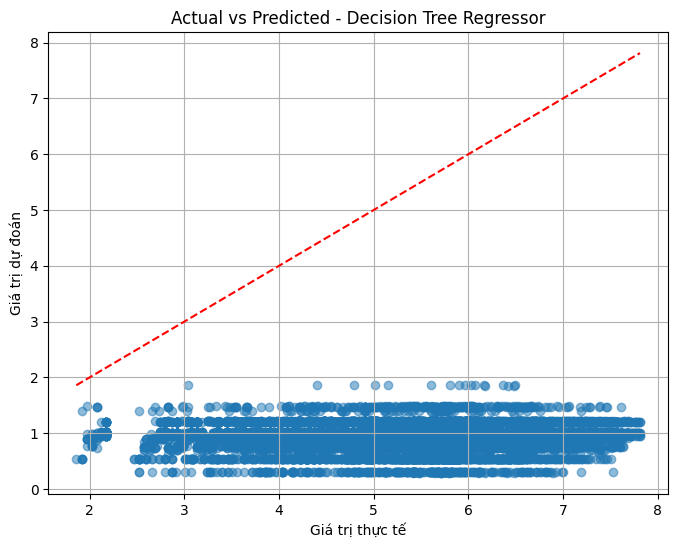

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('Actual vs Predicted - Decision Tree Regressor')
plt.grid(True)
plt.show()

### Nhận xét biểu đồ Actual vs Predicted

Biểu đồ thể hiện mối quan hệ giữa **giá trị thực (Actual)** và **giá trị dự đoán (Predicted)** của mô hình Decision Tree Regressor.

- Đường chéo màu đỏ biểu diễn trường hợp dự đoán hoàn hảo, trong đó giá trị dự đoán bằng giá trị thực.
- Các điểm dữ liệu phân bố rất xa đường chéo và chủ yếu tập trung trong khoảng **0.3–1.5** trên trục tung, trong khi giá trị thực trải rộng từ khoảng **2 đến gần 8**.
- Giá trị dự đoán gần như không thay đổi nhiều theo giá trị thực, cho thấy mô hình không nắm bắt được xu hướng của dữ liệu.
- Khi giá trị thực tăng, mô hình vẫn dự đoán quanh một khoảng giá trị thấp, dẫn đến sai số lớn đối với hầu hết các quan sát.
- Sự phân tán lớn của các điểm so với đường dự đoán lý tưởng phản ánh khả năng dự đoán của mô hình rất kém.

### Kết luận

Biểu đồ cho thấy mô hình **Decision Tree Regressor** chưa học được mối quan hệ giữa các đặc trưng và biến mục tiêu. Điều này phù hợp với kết quả đánh giá khi **R² trên tập kiểm tra âm** và các chỉ số lỗi (MAE, MSE, RMSE) còn cao. Mô hình hiện tại chưa có khả năng tổng quát hóa tốt và cần được cải thiện thông qua việc tiền xử lý dữ liệu, lựa chọn đặc trưng hoặc điều chỉnh siêu tham số.

## 7. Residual Plot (Biểu đồ Sai số)

**Mục tiêu:**  
Xem mô hình sai lệch bao nhiêu so với giá trị thực tế.

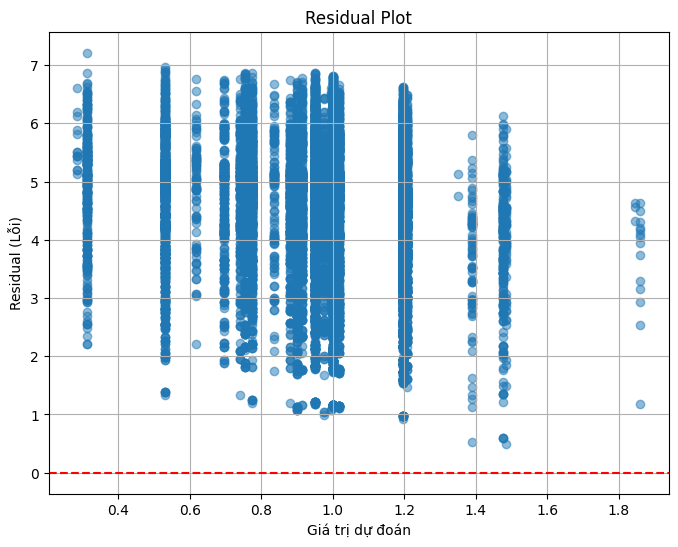

In [8]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán')
plt.ylabel('Residual (Lỗi)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()